# Import de bibliothèques

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle

# Crashs

On trace un histogramme pour chaque fonction reward et chaque modèle pour le nombre de crash obtenu au dernier test après 100 000 itérations.

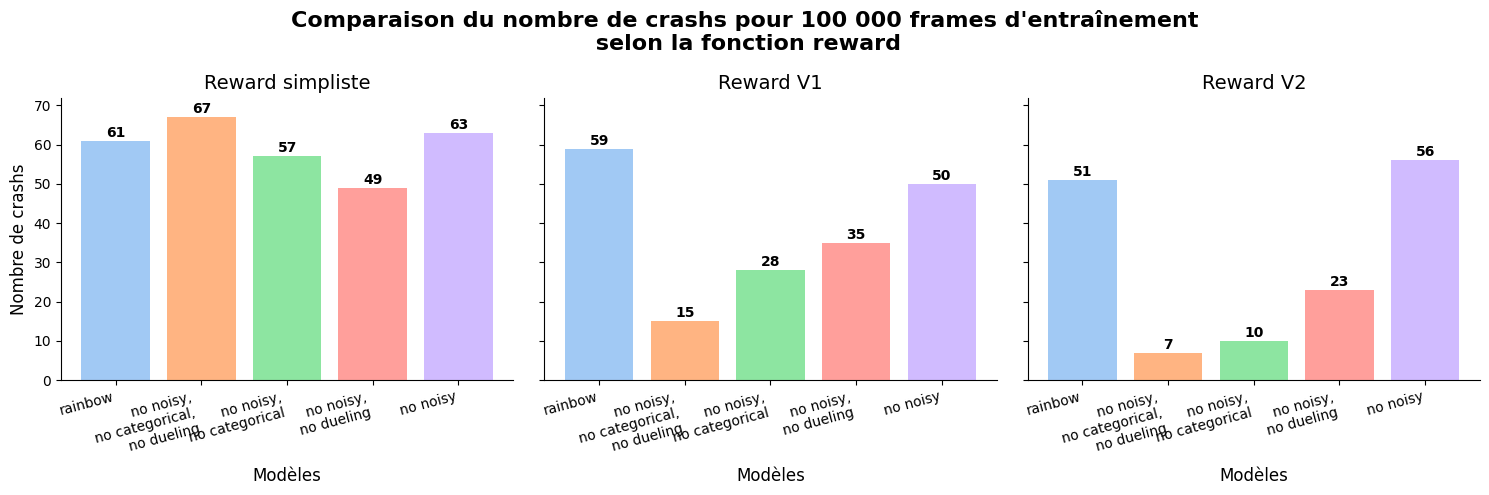

In [2]:
# Modèles (les mêmes pour toutes les expériences)
modeles = [
    "rainbow",
    "no noisy,\nno categorical,\nno dueling",
    "no noisy,\nno categorical",
    "no noisy,\nno dueling",
    "no noisy"
]

# Nombre de crashs pour chaque modèle rentré à la main grâce au tableau excel du dossier résultat
crashs_r1 = [59, 15, 28, 35, 50] 
crashs_r2 = [51,7,10,23, 56]
crashs_r3 = [61, 67, 57, 49,63]

# Palette de couleurs
couleurs = sns.color_palette("pastel", len(modeles))

# Création de la figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle("Comparaison du nombre de crashs pour 100 000 frames d'entraînement\n selon la fonction reward", fontsize=16, fontweight="bold")

# Liste des expériences
crashs_list = [crashs_r3, crashs_r1, crashs_r2]
titres = ["Reward simpliste", "Reward V1", "Reward V2"]

for i, ax in enumerate(axes):
    bars = ax.bar(modeles, crashs_list[i], color=couleurs)
    ax.set_title(titres[i], fontsize=14)
    ax.set_xlabel("Modèles", fontsize=12)
    if i == 0:
        ax.set_ylabel("Nombre de crashs", fontsize=12)
    ax.set_ylim(0, max(max(crashs_r1), max(crashs_r2), max(crashs_r3)) + 5)
    
    # Affichage des valeurs sur les barres
    for bar, v in zip(bars, crashs_list[i]):
        ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v), ha='center', fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(modeles)))
    ax.set_xticklabels(modeles, rotation=15, ha='right')
    
# Ajustement de l'espacement
plt.tight_layout()
sns.despine()

plt.show()

# Score reward V2 après 100 000 frames d'entraînement

In [3]:
num_frames = 100000
ss_num_frames = 5000

In [6]:
noms_agents = ["rainbow", "no_three", "no_noisy_no_categ","no_noisy_no_duel", "no_noisy"]

# Récupération des scores avec les listes qu'on a enregistré
def load_score():
    """Charge les scores sauvegardés."""
    score_agents = []
    for i in range(len(noms_agents)):
        filename = f"./resultat/scores/score_agents_" + noms_agents[i] + "_" + str(num_frames) + ".pkl"
        with open(filename, "rb") as f:
            score_agents.append(pickle.load(f)[0])
    return score_agents

score_agents = load_score()

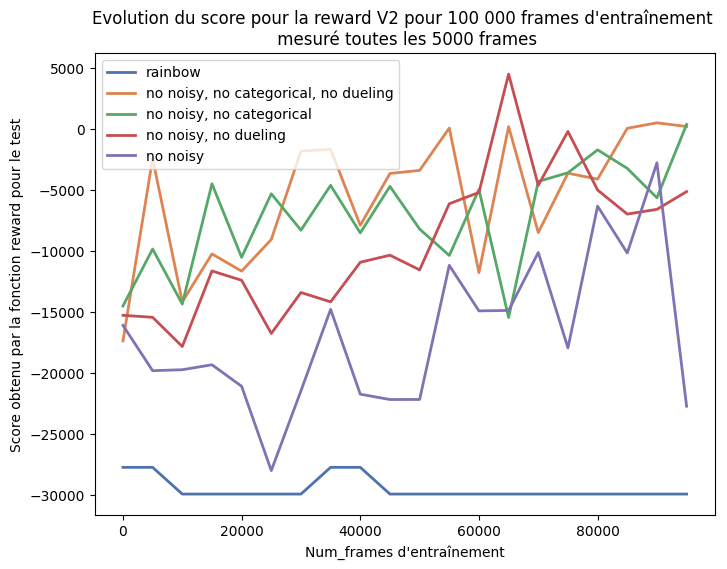

In [7]:
liste_frames = np.arange(0, num_frames, ss_num_frames)
liste_label = ["rainbow", "no noisy, no categorical, no dueling", "no noisy, no categorical", "no noisy, no dueling", "no noisy"]

# Générer une palette de 5 couleurs harmonieuses
colors = sns.color_palette("deep", n_colors=len(liste_label))

# Création de la figure et du graphe
plt.figure(figsize=(8, 6))
plt.title("Evolution du score pour la reward V2 pour 100 000 frames d'entraînement \n mesuré toutes les 5000 frames")

# Tracer les courbes
for i in range(len(liste_label)):
    plt.plot(liste_frames, score_agents[i], label=liste_label[i], color=colors[i], linewidth=2)

# Ajout de la légende et des labels
plt.xlabel("Num_frames d'entraînement")
plt.ylabel(f"Score obtenu par la fonction reward pour le test")
plt.legend()

# Affichage du graphe
plt.show()